In [1]:
import pandas as pd
import ray
import numpy as np
import os
import hyperparam_config as hp_cfg
import matplotlib.pyplot as plt
import config

HP_results_folder_dir = os.path.join(os.getcwd(), 'HP_experiments', 'EarlyStopping')

['HP_ResNet_EndpointLossStopping',
 'HP_ResNet_LayerFreezing',
 'HP_ResNet_MeanLoss',
 'HP_ResNet_MeanLossFreezing']

HP_exp_name = "HP_DCNN_Pooling"
HP_exp_name = "HP_ViT"
HP_exp_name = "HP_DCNN_Pooling_ECE"
HP_exp_name = "HP_ResNet_ECE"
HP_exp_name = "HP_TL_Dose_Predictor"
HP_exp_name = "HP_ResNeXt"
#HP_exp_name = "HP_EfficientNet"

HP_exp_name = "TRP_Dense_0"
HP_exp_name = "TRP_Res_0"
HP_exp_name = "HP_Swin3D"

HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', "HP_DCNN_0")
HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', "DCNN", "HP_DCNN_Pooling")
HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', "DCNN", "HP_DCNN_Multihot")
HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', "DCNN", "HP_DCNN_MixUp")
HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', "HP_ViT")

HP_results_dir = os.path.join(os.getcwd(), 'HP_experiments', HP_exp_name)

C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_14312\433200523.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv(os.path.join(HP_results_dir, 'recovered_results.csv'), delimiter=';', index_col=None)

print(len(df))
df = df[df["done"] == True]
print(len(df))

#df[df['mean_val_AUC'] < 0] = 0
df = df[df['mean_val_AUC'] > 0]
HP_columns = [x for x in df.columns if "config/" in x]
HP_columns.sort()

bool_columns = df.select_dtypes(include=bool).columns
df[bool_columns] = df[bool_columns].astype('str')

df.loc[df['config/loss_function_name'] != 'bce', 'config/label_pos_weights'] = None

#HP_columns = [col for col in HP_columns if col not in df.select_dtypes(include=object).columns]

object_columns = df.select_dtypes(include=object).columns
df[object_columns] = df[object_columns].astype('str')

df["config/lr"] = pd.Categorical(df["config/lr"])


metric_columns = [x for x in df.columns if "val_AUC" in x]
train_metric_columns = [x for x in df.columns if "train_AUC" in x]
val_ECE_metric_columns = [x for x in df.columns if "val_ECE" in x]

132
105


In [68]:
df.sort_values(by='mean_val_AUC', ascending=False, inplace=True)
df[['trial_id'] + train_metric_columns].head(5)


,trial_id,mean_train_AUC,mean_Aspiration_M06_train_AUC,mean_Dysphagia_M06_train_AUC,mean_Sticky_M06_train_AUC,mean_Taste_M06_train_AUC,mean_Xerostomia_M06_train_AUC
8,01c3fe40,0.72704,0.6930,0.8166,0.6852,0.7100,0.7304
90,b5ec51ee,0.73176,0.7050,0.8072,0.6970,0.7178,0.7318
57,71531696,0.72620,0.6980,0.8170,0.6808,0.7034,0.7318
96,5624ecd8,0.74360,0.7470,0.8242,0.6834,0.7218,0.7416
95,7dd05d0d,0.73928,0.7404,0.8178,0.6836,0.7260,0.7286


In [71]:
df.sort_values(by='mean_val_AUC', ascending=False, inplace=True)
df[['trial_id'] + metric_columns].head(5)


,trial_id,mean_val_AUC,mean_Aspiration_M06_val_AUC,mean_Dysphagia_M06_val_AUC,mean_Sticky_M06_val_AUC,mean_Taste_M06_val_AUC,mean_Xerostomia_M06_val_AUC
8,01c3fe40,0.71648,0.6674,0.8144,0.6684,0.7074,0.7248
90,b5ec51ee,0.71592,0.6658,0.7950,0.6878,0.7020,0.7290
57,71531696,0.71196,0.6670,0.8072,0.6636,0.6980,0.7240
96,5624ecd8,0.71044,0.6728,0.8114,0.6454,0.7052,0.7174
95,7dd05d0d,0.70980,0.6648,0.8014,0.6618,0.7110,0.7100


In [72]:
df.sort_values(by='mean_val_AUC', ascending=False, inplace=True)
df[['trial_id'] + val_ECE_metric_columns].head(5)

,trial_id,mean_Aspiration_M06_val_ECE,mean_Dysphagia_M06_val_ECE,mean_Sticky_M06_val_ECE,mean_Taste_M06_val_ECE,mean_Xerostomia_M06_val_ECE
8,01c3fe40,0.0366,0.1014,0.0756,0.0754,0.1354
90,b5ec51ee,0.0978,0.1164,0.0870,0.0788,0.1022
57,71531696,0.1318,0.1428,0.0750,0.1056,0.1204
96,5624ecd8,0.0980,0.1692,0.1796,0.1552,0.1726
95,7dd05d0d,0.0930,0.1700,0.1786,0.1588,0.1756


In [73]:
df.sort_values(by='mean_val_AUC', ascending=False, inplace=True)
df.trial_id.head(5)

8     01c3fe40
90    b5ec51ee
57    71531696
96    5624ecd8
95    7dd05d0d
Name: trial_id, dtype: object

In [74]:
import config


for toxicity in config.endpoint_list:
    df_tox = df.copy()
    df_tox.sort_values(by=f"mean_{toxicity}_val_AUC", ascending=False, inplace=True)
    #df_tox.head(3)
    print(f"\nBest {toxicity} model")
    print(df_tox[f"mean_{toxicity}_train_AUC"].head(1))
    print(df_tox[f"mean_{toxicity}_val_AUC"].head(1))


Best Aspiration_M06 model
64    0.7458
Name: mean_Aspiration_M06_train_AUC, dtype: float64
64    0.7076
Name: mean_Aspiration_M06_val_AUC, dtype: float64

Best Dysphagia_M06 model
8    0.8166
Name: mean_Dysphagia_M06_train_AUC, dtype: float64
8    0.8144
Name: mean_Dysphagia_M06_val_AUC, dtype: float64

Best Sticky_M06 model
90    0.697
Name: mean_Sticky_M06_train_AUC, dtype: float64
90    0.6878
Name: mean_Sticky_M06_val_AUC, dtype: float64

Best Taste_M06 model
95    0.726
Name: mean_Taste_M06_train_AUC, dtype: float64
95    0.711
Name: mean_Taste_M06_val_AUC, dtype: float64

Best Xerostomia_M06 model
90    0.7318
Name: mean_Xerostomia_M06_train_AUC, dtype: float64
90    0.729
Name: mean_Xerostomia_M06_val_AUC, dtype: float64


# PLOTS!


In [75]:
import pandas as pd
import os
from sklearn.preprocessing import OneHotEncoder


# drop failed columns
df = df[df['mean_val_AUC'] > 0]

# make the trial_id a string
df['trial_id'] = df['trial_id'].astype(pd.StringDtype())

# the columns that are in list form (and which are thus not nice to plot)
concated_params = ['filters', 'kernel_sizes', 'strides', 'linear_units',
                   #'dropout_p', 
                   'clinical_variables_linear_units', 'clinical_variables_dropout_p', 
                   'linear_units_endpoint', 'dropout_p_endpoint', "mixture_depth", "swin"]

config_columns = [col for col in df.columns if ("config/" in col) and (col.replace("config/", "") not in concated_params)]
config_columns.sort()

main_config_cols = [col for col in config_columns if not col[-1].isdigit()]
layer_based_config_cols = [col for col in config_columns if col[-1].isdigit()]

main_config_cols.sort()
layer_based_config_cols.sort()

# sort the dataframe by date
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d_%H-%M-%S')
df.sort_values(by=['date'], inplace=True, ignore_index=True)
df['trial_numbers'] = list(range(len(df)))
#df['date'].sort_values(inplace=True)

df["config/lr"] = df["config/lr"].astype("category")

df['config/features_dl'] = df['config/features_dl'].astype('str')

# Create an instance of the OneHotEncoder
encoder = OneHotEncoder()

# Fit and transform the column you want to one-hot encode
df['config/features_dl'] = encoder.fit_transform(df['config/features_dl'].values.reshape(-1, 1)).toarray()[:, 0]

In [76]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.colors as colors


COLOR_SCALE_MAIN = colors.sequential.YlGn
#COLOR_SCALE = COLOR_SCALE_MAIN[len(COLOR_SCALE_MAIN)//4:]
COLOR_SCALE = COLOR_SCALE_MAIN
#background_color = colors.sequential.YlGn[0]


def plot_hyperparameter_results(df, parameter_columns, metric_column, title):
    num_subplots = len(parameter_columns)
    param_col_plot_titles = [column.replace("config/", "") for column in parameter_columns]

    #names = [str(trial_id) for trial_id in df['trial_id']]
    #print(names)
    #df['trial_id'].astype(str).split()[1]

    fig = make_subplots(rows=1, cols=len(parameter_columns), shared_yaxes=False, subplot_titles=param_col_plot_titles)
    fig.update_layout(title=HP_exp_name + " " + title)
    fig.update_layout(template="ggplot2")
    for idx, col in enumerate(parameter_columns, start=1):
        fig.add_trace(
            go.Scatter(x=df[col], y=df['mean_val_AUC'], mode='markers', 
                    text=df['trial_id'],

                    marker={"colorscale": COLOR_SCALE, 
                            "color": df['trial_numbers'],
                            #"marker_line":2,
                            "colorbar": {
                                "title": "Trial",
                                "x": 1.0,
                                "xpad": 40
                            },
                            "line": dict(
                                    color=COLOR_SCALE_MAIN[-1],
                                     width=0.5
                                )
                            }, 
                        hovertemplate="<b>%{text}</b><br>value=%{x}<br> AUC=%{y:.4f}<extra></extra>",
                        ), 
            row=1, col=idx
            )

    # fig.update_layout(
    #     plot_bgcolor=background_color
    # )
    fig.update_layout(showlegend=False)          # hide the legend 
    fig.update_layout(width=300 * num_subplots)  # ensure each subplot is wide enough
    fig.show()
    #fig.title = "hello"
    path = os.path.join(HP_results_dir, title+".html")
    fig.write_html(path)              # save to html

plot_hyperparameter_results(df, main_config_cols, "mean_val_AUC", "Main Hyperparameters")
plot_hyperparameter_results(df, layer_based_config_cols, "mean_val_AUC", "Layer Based Hyperparameters")

In [78]:
plot_hyperparameter_results(df, metric_columns, "mean_val_AUC", "Metric Columns")

In [79]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

metric_column = 'mean_val_AUC'

running_best_AUC = 0
best_AUC_values = []
best_values_index = []

for idx, row in df.iterrows():
    #print(idx)
    #best_values_index.append(idx)
    if row[metric_column] > running_best_AUC:
        running_best_AUC = row[metric_column]
        best_AUC_values.append(running_best_AUC)
        best_values_index.append(row['trial_numbers'])

# add a point at the end of the lists to make the line reach the end of the plot
best_AUC_values.append(running_best_AUC)
best_values_index.append(df['trial_numbers'].max())


# Create a scatter plot for the highest values
fig = go.Figure()
fig.update_layout(template="ggplot2")

# Add scatter plot for the highest values over time
fig.add_trace(go.Scatter(x=df['trial_numbers'], 
                         y=df[metric_column], 
                         text=df['trial_id'],
                         mode='markers', 
                         name='Trial',
                         hovertemplate="<b>%{text}</b><br>Trial # %{x}<br> AUC=%{y:.4f}",
                         line_color='rgb(0,104,55)',
                         )
                         )

fig.add_trace(go.Scatter(x=best_values_index, y=best_AUC_values, mode='lines', name='Running Best', line_color= 'rgb(173,221,142)'))



# Set axis titles
fig.update_layout(
    title=HP_exp_name + " Highest AUC Values Over Trials",
    xaxis_title="Trial Number",
    yaxis_title="Highest AUC Value",
    showlegend=False,
)
# Display the figure
fig.show()

path = os.path.join(HP_results_dir, "Timeline.html")
fig.write_html(path)              # save to html


In [50]:
mean_AUC_columns = [col for col in df.columns if ("val_" in col or 'train_' in col)]
mean_AUC_columns

df_metrics = df[mean_AUC_columns + ['trial_id']]


df_metrics = df_metrics.sort_values(by=['mean_val_AUC'], ascending=False, ignore_index=True)
df_metrics.head(3)

,mean_train_AUC,mean_val_AUC,mean_Aspiration_M06_train_AUC,mean_Aspiration_M06_val_AUC,mean_Aspiration_M06_val_ECE,mean_Dysphagia_M06_train_AUC,mean_Dysphagia_M06_val_AUC,mean_Dysphagia_M06_val_ECE,mean_Sticky_M06_train_AUC,mean_Sticky_M06_val_AUC,mean_Sticky_M06_val_ECE,mean_Taste_M06_train_AUC,mean_Taste_M06_val_AUC,mean_Taste_M06_val_ECE,mean_Xerostomia_M06_train_AUC,mean_Xerostomia_M06_val_AUC,mean_Xerostomia_M06_val_ECE,train_loss,val_loss,trial_id
0,0.77460,0.73804,0.7708,0.6878,0.0262,0.8532,0.8284,0.0744,0.7184,0.6814,0.0734,0.7604,0.7434,0.0726,0.7702,0.7492,0.0830,0.463642,0.477966,cd02e4d7
1,0.76908,0.73404,0.7616,0.7038,0.0224,0.8414,0.8256,0.0756,0.7176,0.6926,0.0722,0.7596,0.7124,0.0668,0.7652,0.7358,0.0634,0.467453,0.480709,578913c9
2,0.74688,0.72300,0.7264,0.6774,0.0356,0.8342,0.8148,0.0692,0.6966,0.6764,0.0556,0.7284,0.7084,0.0692,0.7488,0.7380,0.1008,0.486855,0.494278,62cb96a6


In [51]:
top_three_trial_ids = df_metrics['trial_id'].head(3).to_list()
top_three_trial_ids

['cd02e4d7', '578913c9', '62cb96a6']

In [47]:
config.endpoint_list

['Aspiration_M06',
 'Dysphagia_M06',
 'Sticky_M06',
 'Taste_M06',
 'Xerostomia_M06']

In [48]:
import misc 
import config

dir = os.path.join("experiments", "HP_ResNet_EndpointLossStopping")

#print(os.listdir(dir))
trial_folders = [x for x in os.listdir(dir) if os.path.isdir(os.path.join(dir, x))]

for t_id in trial_folders:
    #print()

    trial_fold_folders = [x for x in os.listdir(os.path.join(dir, t_id)) if os.path.isdir(os.path.join(dir, t_id, x))]
    #trial_folders = [x for x in trial_folders if x.split("_")[2] in []]
    for fold_folder in trial_fold_folders:
        try:
            trial_folder_path = os.path.join(dir, t_id, fold_folder)
            #print(os.listdir(path))
            files = os.listdir(trial_folder_path)
            all_outputs_csv = [x for x in files if "all_outputs.csv" in x][0]
            #print(s.path.join(trial_folder_path, all_outputs_csv))
            df_outputs = pd.read_csv(os.path.join(trial_folder_path, all_outputs_csv), delimiter=';') # load predictions csv
            df_outputs = df_outputs[df_outputs['Mode'] == "val"] # keep only the validation data
            #print(len(df_outputs))

            predictions_dict = {}
            true_labels_dict = {}
            for endpoint in config.endpoint_list:
                predictions_dict[endpoint] = df_outputs[endpoint + "_pred"].to_numpy()
                true_labels_dict[endpoint] = df_outputs[endpoint + "_true"].to_numpy()
            cal_plot_path = os.path.join(trial_folder_path, 'calibration_plot_validation.png')
            misc.make_calibration_plot(config, predictions_dict, true_labels_dict, set_name="Validation", filename=cal_plot_path)
            plt.close()
        except Exception as e:
            #print("EXCEPTION:", e)
            pass
    #print(trial_folders)
    

    # folders = os.listdir(os.path.join(dir, t_id))
    # print(len(folders))
    # print(folders)

    # for fold in folders:
        
    #     try:
    #         #print(fold.split("_"))
    #         if fold.split("_")[2] == "5":
    #             print(fold)
    #     except:
    #         pass
    #         #print(os.path.join(dir, t_id, fold))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'experiments\\HP_ResNet_EndpointLossStopping'

In [84]:
clinical_cols = [col for col in layer_based_config_cols if "clinical" in col]
endpoint_cols = [col for col in layer_based_config_cols if "endpoint" in col]
shared_cols = [col for col in layer_based_config_cols if "shared" in col]
CNN_cols = [col for col in layer_based_config_cols if col not in clinical_cols+endpoint_cols+shared_cols]

In [85]:
print(clinical_cols)
print(endpoint_cols)
print(shared_cols)
print(CNN_cols)

['config/clinical_variables_dropout_p_0', 'config/clinical_variables_dropout_p_1', 'config/clinical_variables_dropout_p_2', 'config/clinical_variables_dropout_p_3', 'config/clinical_variables_dropout_p_4', 'config/clinical_variables_dropout_p_5', 'config/clinical_variables_linear_layer_0', 'config/clinical_variables_linear_layer_1', 'config/clinical_variables_linear_layer_2', 'config/clinical_variables_linear_layer_3', 'config/clinical_variables_linear_layer_4', 'config/clinical_variables_linear_layer_5']
[]
['config/shared_dropout_p_0', 'config/shared_dropout_p_1', 'config/shared_dropout_p_2', 'config/shared_dropout_p_3', 'config/shared_dropout_p_4', 'config/shared_dropout_p_5', 'config/shared_linear_layer_0', 'config/shared_linear_layer_1', 'config/shared_linear_layer_2', 'config/shared_linear_layer_3', 'config/shared_linear_layer_4', 'config/shared_linear_layer_5']
['config/T_0', 'config/filters_0', 'config/filters_1', 'config/filters_2', 'config/filters_3', 'config/filters_4', 'con

<Axes: xlabel='config/loss_function_name', ylabel='config/lr'>

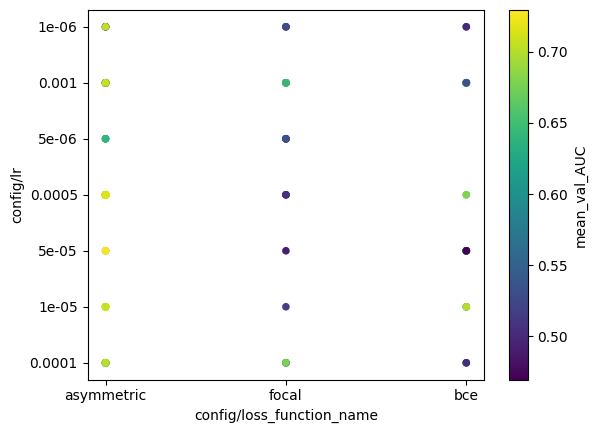

In [41]:
df['config/lr'] = df['config/lr'].astype(str)

df.plot.scatter("config/loss_function_name", "config/lr", c="mean_val_AUC")